In [1]:
import math, random
import numpy as np
import pandas as pd
from collections import defaultdict
from helpers import *
import os
import json

In [2]:
# === CONFIG === #
output_dir = "output/after3rdMatchday/"
os.makedirs(output_dir, exist_ok=True)

N_SIM = 10000
ELO_SIGMA = 70.0   # scale of algorithmic ELO calculation
ALPHA = 1.0         # weight of ppg (points per game)
BETA = 0.8          # weight of gd_pg (goal diff per game)
GAMMA = 0.2         # weight of gf_pg (goals scored per game)
K_FACTOR = 20       # ELO update factor
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [3]:
# === Actual table status === #
teams_data = {
    "EKO-RAFF": {"M": 3, "W": 3, "D": 0, "L": 0, "GF": 23, "GA": 6, "GD": 17, "Pts": 9},
    "Banger W-wa": {"M": 3, "W": 2, "D": 0, "L": 1, "GF": 9, "GA": 9, "GD": 0, "Pts": 6},
    "FC Otamany": {"M": 2, "W": 2, "D": 0, "L": 0, "GF": 21, "GA": 8, "GD": 13, "Pts": 6},
    "Eternis Księgowość": {"M": 3, "W": 2, "D": 0, "L": 1, "GF": 13, "GA": 11, "GD": 2, "Pts": 6},
    "La Masia": {"M": 3, "W": 2, "D": 0, "L": 1, "GF": 13, "GA": 14, "GD": -1, "Pts": 6},
    "Fakel": {"M": 2, "W": 1, "D": 0, "L": 1, "GF": 16, "GA": 9, "GD": 7, "Pts": 3},
    "Inferno Team": {"M": 3, "W": 1, "D": 0, "L": 2, "GF": 14, "GA": 25, "GD": -11, "Pts": 3},
    "Tune Squad": {"M": 3, "W": 0, "D": 1, "L": 2, "GF": 3, "GA": 7, "GD": -4, "Pts": 1},
    "Cyrkulatka": {"M": 3, "W": 0, "D": 1, "L": 2, "GF": 4, "GA": 10, "GD": -6, "Pts": 1},
    "Niski Press": {"M": 3, "W": 0, "D": 0, "L": 3, "GF": 11, "GA": 28, "GD": -17, "Pts": 0}
}

file_path = os.path.join(output_dir, "teams_data.json")

with open(file_path, "w", encoding="utf-8") as f:
    json.dump(teams_data, f, ensure_ascii=False, indent=4)

teams = list(teams_data.keys())

In [4]:
# === Manual ELO ratings (optional) === #
manual_elo = {
#   Cyrkulatka     : 1591
#   EKO-RAFF       : 1672
#   Fakel          : 1579
#   Banger W-wa    : 1555
#   Inferno Team   : 1552
#   KPT Warszawa   : 1457
#   Mitra          : 1432
#   Blic Team      : 1428
#   Tune Squad     : 1406
#   CPI            : 1328
}
# If manual_elo is empty, an algorithmic way of calculating ELO will be used

In [5]:
remaining_matches = [
('EKO-RAFF', 'Niski Press'), ('Inferno Team', 'Banger W-wa'), ('Fakel', 'Tune Squad'), ('Cyrkulatka', 'Eternis Księgowość'), ('La Masia', 'FC Otamany'), 
('EKO-RAFF', 'Fakel'), ('Inferno Team', 'Tune Squad'), ('FC Otamany', 'Eternis Księgowość'), ('La Masia', 'Niski Press'), ('Cyrkulatka', 'Banger W-wa'), 
('EKO-RAFF', 'FC Otamany'), ('Tune Squad', 'Niski Press'), ('Fakel', 'Banger W-wa'), ('Inferno Team', 'Cyrkulatka'), ('La Masia', 'Eternis Księgowość'), 
('FC Otamany', 'Cyrkulatka'), ('Tune Squad', 'EKO-RAFF'), ('Niski Press', 'Inferno Team'), ('Banger W-wa', 'La Masia'), ('Fakel', 'Eternis Księgowość'), 
('Fakel', 'Inferno Team'), ('EKO-RAFF', 'Eternis Księgowość'), ('Banger W-wa', 'FC Otamany'), ('Tune Squad', 'La Masia'), ('Niski Press', 'Cyrkulatka'), 
('EKO-RAFF', 'La Masia'), ('Inferno Team', 'Eternis Księgowość'), ('Tune Squad', 'FC Otamany'), ('Niski Press', 'Banger W-wa'), ('Fakel', 'Cyrkulatka')
]

file_path = os.path.join(output_dir, "remaining_matches.json")

with open(file_path, "w", encoding="utf-8") as f:
    json.dump(remaining_matches, f, ensure_ascii=False, indent=4)

In [6]:
if manual_elo:
    elo0 = manual_elo.copy()
    # ensure all teams present
    for t in teams:
        if t not in elo0:
            elo0[t] = 1500
else:
    elo0 = compute_auto_elo(teams_data, alpha=ALPHA, beta=BETA, gamma=GAMMA, sigma=ELO_SIGMA)

draw_prob = estimate_draw_prob(teams_data)

print("Starting ELO:")
for t in teams:
    print(f"  {t:15s}: {elo0[t]}")

print(f"Estimated prob of draw from previous matches: {draw_prob:.3f}")
print(f"Number of simulations: {N_SIM}. Number of remaining matches: {len(remaining_matches)}")

Starting ELO:
  EKO-RAFF       : 1602
  Banger W-wa    : 1498
  FC Otamany     : 1621
  Eternis Księgowość: 1510
  La Masia       : 1498
  Fakel          : 1551
  Inferno Team   : 1440
  Tune Squad     : 1447
  Cyrkulatka     : 1440
  Niski Press    : 1395
Estimated prob of draw from previous matches: 0.100
Number of simulations: 10000. Number of remaining matches: 30


In [7]:
# === SIMULATIONS === #
results_count = {t: np.zeros(len(teams)+1, dtype=int) for t in teams}  # positions 1..10 prep array
points_initial = {t: teams_data[t]["Pts"] for t in teams}
gd_initial = {t: teams_data[t]["GD"] for t in teams}
gf_initial = {t: teams_data[t]["GF"] for t in teams}
ga_initial = {t: teams_data[t]["GA"] for t in teams}
points_for_title = []
points_for_safety = []
match_outcomes = {
    pair: {"A_wins": 0, "Draws": 0, "B_wins": 0, "count": 0}
    for pair in remaining_matches
}

for sim in range(N_SIM):
    pts = points_initial.copy()
    elo = elo0.copy()

    for (a, b) in remaining_matches:
        pa, pdraw, pb = match_probs(elo0[a], elo0[b], draw_prob)
        r = random.random()
        if r < pa:  # A wins
            pts[a] += 3
            S_A, S_B = 1.0, 0.0
            match_outcomes[(a, b)]["A_wins"] += 1
        elif r < pa + pdraw:  # Draw
            pts[a] += 1
            pts[b] += 1
            S_A, S_B = 0.5, 0.5
            match_outcomes[(a, b)]["Draws"] += 1
        else:  # B wins
            pts[b] += 3
            S_A, S_B = 0.0, 1.0
            match_outcomes[(a, b)]["B_wins"] += 1

        match_outcomes[(a, b)]["count"] += 1
        elo[a], elo[b] = update_elo(elo[a], elo[b], S_A, S_B, K=K_FACTOR)

    # sorting by points
    items = list(pts.items())
    random.shuffle(items)   # shuffle to avoid bias in equal keys before sorting by tiebreakers
    items.sort(key=lambda x: (x[1]), reverse=True)

    points_for_title.append(items[0][1])   # store points for 1st place
    points_for_safety.append(items[7][1])  # store points for 8th place

    for pos, (team, p) in enumerate(items, start=1):
        results_count[team][pos] += 1

In [8]:
# === Remaining matches summary === #
records = []
for (a, b), s in match_outcomes.items():
    total = s["count"]
    if total > 0:
        records.append({
            "Team A": a,
            "A_win_%": s["A_wins"] / total * 100,
            "Draw_%":  s["Draws"] / total * 100,
            "B_win_%": s["B_wins"] / total * 100,
            "Team B": b
        })
df_wdl = pd.DataFrame(records).round(1)

file_path = os.path.join(output_dir, "next_matchday_probs.json")

with open(file_path, "w", encoding="utf-8") as f:
    json.dump(df_wdl[0:5].to_dict(orient="records"), f, ensure_ascii=False, indent=4)

df_wdl[0:5]

,Team A,A_win_%,Draw_%,B_win_%,Team B
0,EKO-RAFF,69.1,10.0,20.9,Niski Press
1,Inferno Team,37.6,9.9,52.5,Banger W-wa
2,Fakel,58.5,10.0,31.5,Tune Squad
3,Cyrkulatka,35.8,9.8,54.4,Eternis Księgowość
4,La Masia,30.3,10.1,59.6,FC Otamany


In [9]:
# === RESULTS === #
prob_table = pd.DataFrame(index=teams, columns=[f"pos_{i}" for i in range(1, len(teams)+1)], dtype=float)
for t in teams:
    for pos in range(1, len(teams)+1):
        prob_table.loc[t, f"pos_{pos}"] = results_count[t][pos] / N_SIM

prob_table = prob_table.loc[sorted(teams, key=lambda x: -teams_data[x]["Pts"])]  # sort by current standings
pd.set_option("display.precision", 3)

# additionally: probs of top-3 and relegaiton (places 9 & 10)
summary = pd.DataFrame(index=teams, columns=["P_top3","P_relegation_9_10"])
for t in teams:
    summary.loc[t, "P_top3"] = prob_table.loc[t, ["pos_1","pos_2","pos_3"]].sum()
    summary.loc[t, "P_relegation_9_10"] = prob_table.loc[t, ["pos_9","pos_10"]].sum()

avg_points_title = np.mean(points_for_title)
avg_points_safety = np.mean(points_for_safety)
print(f"Estimated points needed for title: {avg_points_title:.2f}")
print(f"Estimated points needed to avoid relegation (8th place): {avg_points_safety:.2f}")

file_path = os.path.join(output_dir, "estimated_points_needed.json")
points_needed = {
    "points_for_title": avg_points_title,
    "points_for_safety": avg_points_safety
}
with open(file_path, "w", encoding="utf-8") as f:
    json.dump(points_needed, f, ensure_ascii=False, indent=4)

Estimated points needed for title: 21.40
Estimated points needed to avoid relegation (8th place): 8.87


c:\Users\jezna\anaconda3\envs\srod1\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


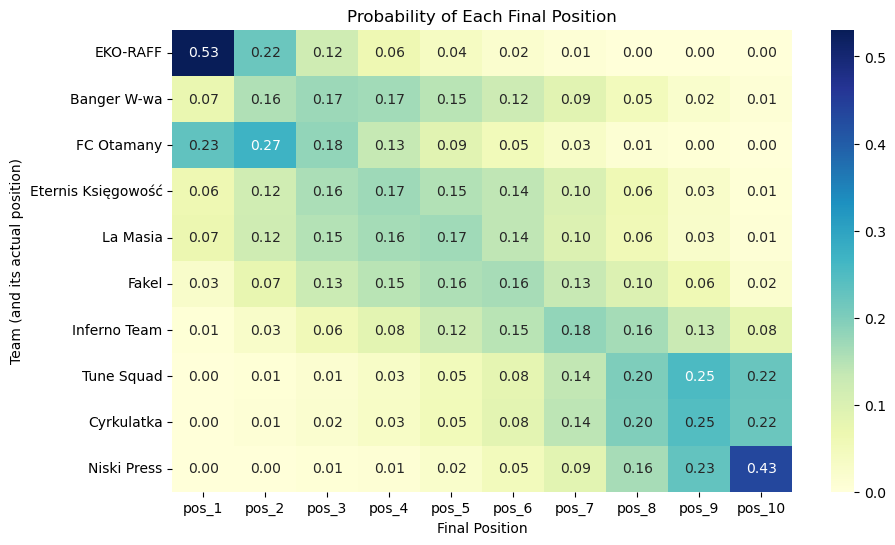

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

file_path = os.path.join(output_dir, "prob_table.json")
with open(file_path, "w", encoding="utf-8") as f:
    json.dump(prob_table.to_dict(orient="index"), f, ensure_ascii=False, indent=4)

plt.figure(figsize=(10,6))
sns.heatmap(prob_table, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Probability of Each Final Position")
plt.xlabel("Final Position")
plt.ylabel("Team (and its actual position)")
plt.show()

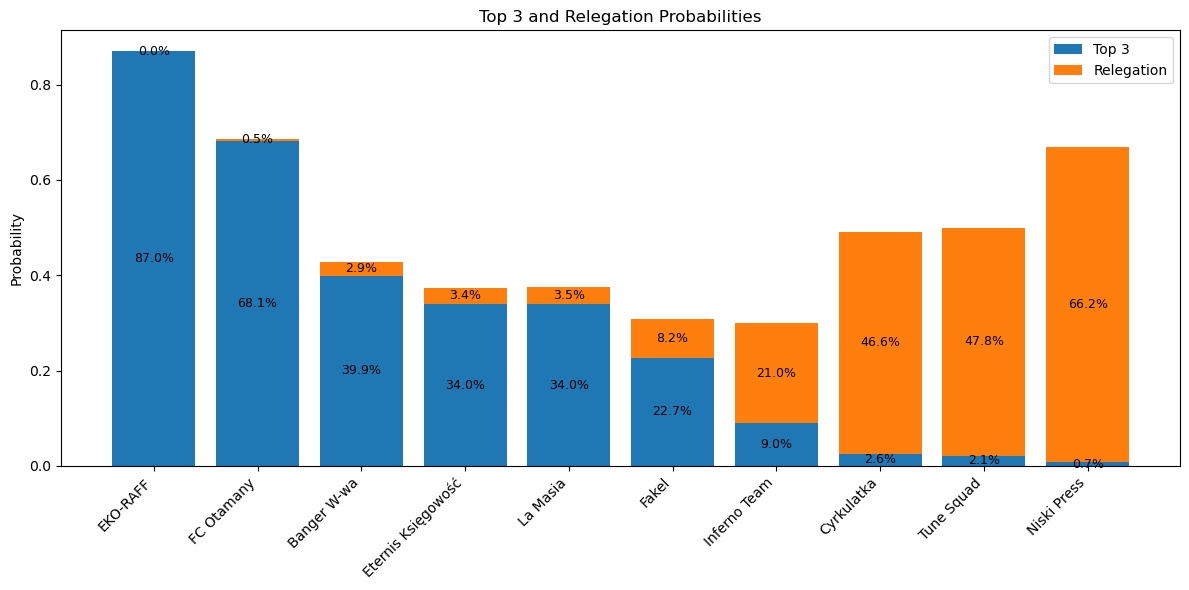

In [11]:
summary_sorted = summary.sort_values("P_top3", ascending=False)

fig, ax = plt.subplots(figsize=(12,6))

top3 = summary_sorted["P_top3"]
releg = summary_sorted["P_relegation_9_10"]

# słupki skumulowane
ax.bar(summary_sorted.index, top3, label="Top 3")
ax.bar(summary_sorted.index, releg, bottom=top3, label="Relegation")

# etykiety procentowe (tylko jeśli > 0)
for i, team in enumerate(summary_sorted.index):
    if top3.iloc[i] > 0:
        ax.text(
            i,
            top3.iloc[i] / 2,
            f"{top3.iloc[i]*100:.1f}%",
            ha="center",
            va="center",
            fontsize=9
        )
    if releg.iloc[i] > 0:
        ax.text(
            i,
            top3.iloc[i] + releg.iloc[i] / 2,
            f"{releg.iloc[i]*100:.1f}%",
            ha="center",
            va="center",
            fontsize=9
        )

ax.set_ylabel("Probability")
ax.set_title("Top 3 and Relegation Probabilities")
ax.set_xticks(range(len(summary_sorted.index)))
ax.set_xticklabels(summary_sorted.index, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

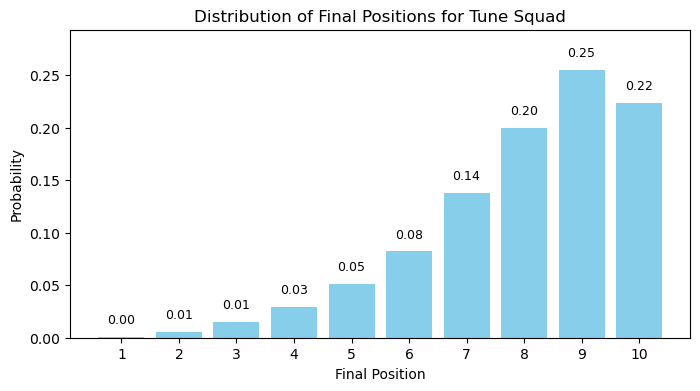

In [12]:
team = "Tune Squad"
positions = np.arange(1, len(teams) + 1)
probs = prob_table.loc[team]

plt.figure(figsize=(8,4))
bars = plt.bar(positions, probs, color="skyblue")

for bar, prob in zip(bars, probs):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{prob:.2f}', 
             ha='center', va='bottom', fontsize=9)

plt.ylim(0, max(probs)*1.15)

plt.xticks(positions)
plt.xlabel("Final Position")
plt.ylabel("Probability")
plt.title(f"Distribution of Final Positions for {team}")
plt.show()